# Probability Mass Function (PMF)

A **Probability Mass Function (PMF)** is the fundamental tool for describing the probability distribution of a **discrete random variable**. It assigns a probability to each possible value the variable can take.

## Definition

Let $X$ be a discrete random variable with possible values $x_1, x_2, x_3, \ldots$

The **PMF** of $X$ is the function:

$$P_X(x) = P(X = x)$$

It tells us the **probability that $X$ takes exactly the value $x$**.

### Properties of a Valid PMF

1. **Non-negativity**: $P_X(x) \geq 0$ for all $x$
2. **Normalization**: $\sum_{x} P_X(x) = 1$ (all probabilities sum to 1)
3. **Zero outside support**: $P_X(x) = 0$ for any $x$ not in the range of $X$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import binom, geom, poisson
from math import comb

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

## Example 1 — Fair Die Roll

Rolling a fair 6-sided die:

- Sample space: $S = \{1, 2, 3, 4, 5, 6\}$
- Random variable $X$ = the face showing
- PMF: $P_X(x) = \dfrac{1}{6}$ for $x \in \{1, 2, 3, 4, 5, 6\}$

This is the **Discrete Uniform** distribution — every outcome is equally likely.

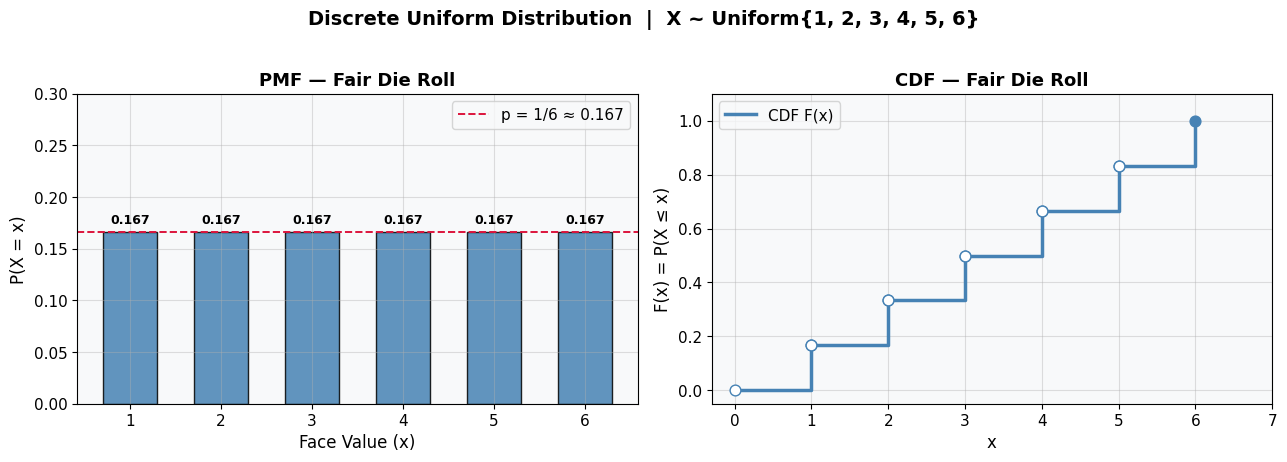

Sum of all PMF values: 1.0000  (must equal 1)


In [2]:
# --- Fair Die Roll (Discrete Uniform) ---
values = np.arange(1, 7)
probs  = np.ones(6) / 6

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# PMF bar chart
ax = axes[0]
bars = ax.bar(values, probs, color='steelblue', edgecolor='black', alpha=0.85, width=0.6)
ax.axhline(1/6, color='crimson', linestyle='--', linewidth=1.4, label=f'p = 1/6 ≈ {1/6:.3f}')
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.005, f'{p:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Face Value (x)', fontsize=12)
ax.set_ylabel('P(X = x)', fontsize=12)
ax.set_title('PMF — Fair Die Roll', fontsize=13, fontweight='bold')
ax.set_xticks(values)
ax.set_ylim(0, 0.30)
ax.legend()

# CDF
ax2 = axes[1]
cdf = np.cumsum(probs)
ax2.step(np.concatenate([[0], values]), np.concatenate([[0], cdf]),
         where='post', color='steelblue', linewidth=2.5, label='CDF F(x)')
ax2.scatter(values, cdf, color='steelblue', zorder=5, s=60)
ax2.scatter(np.concatenate([[0], values[:-1]]), np.concatenate([[0], cdf[:-1]]),
            facecolors='white', edgecolors='steelblue', zorder=5, s=60)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('F(x) = P(X ≤ x)', fontsize=12)
ax2.set_title('CDF — Fair Die Roll', fontsize=13, fontweight='bold')
ax2.set_xticks(range(0, 8))
ax2.set_ylim(-0.05, 1.1)
ax2.legend()

plt.suptitle('Discrete Uniform Distribution  |  X ~ Uniform{1, 2, 3, 4, 5, 6}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Sum of all PMF values: {probs.sum():.4f}  (must equal 1)")

## Example 2 — Two Coin Flips (Number of Heads)

Flip a fair coin twice. Let $X$ = number of heads.

| Outcome | X |
|---------|---|
| TT | 0 |
| HT | 1 |
| TH | 1 |
| HH | 2 |

$$P_X(0) = \frac{1}{4}, \quad P_X(1) = \frac{2}{4} = \frac{1}{2}, \quad P_X(2) = \frac{1}{4}$$

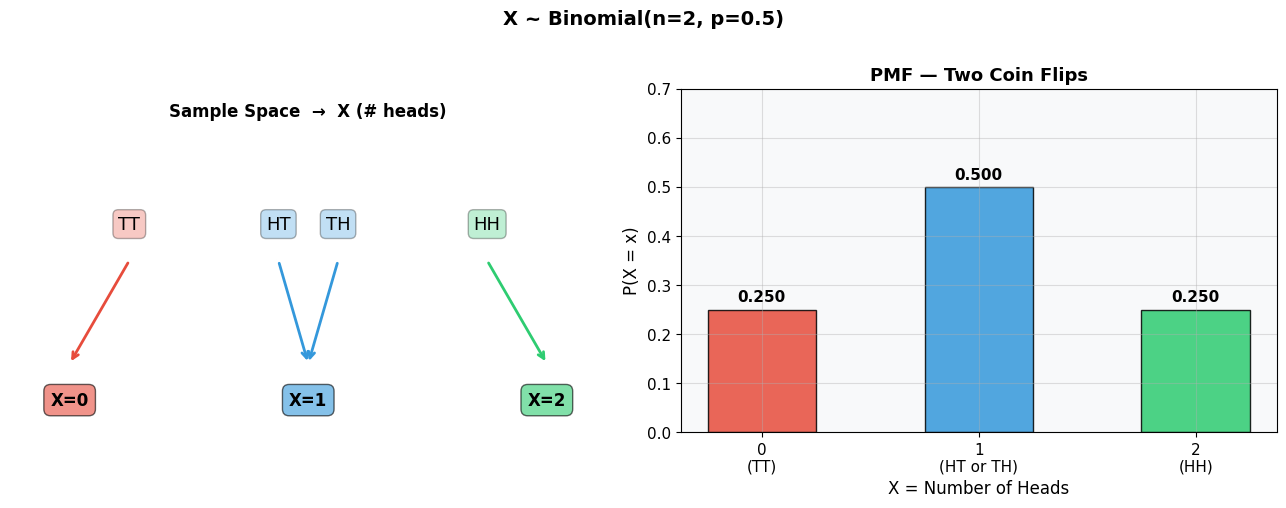

Sum check: 1.0000


In [3]:
# --- Two Coin Flips ---
x_vals = [0, 1, 2]
p_vals = [1/4, 2/4, 1/4]
labels = ['TT\n(0 heads)', 'HT or TH\n(1 head)', 'HH\n(2 heads)']
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sample space illustration
ax0 = axes[0]
outcomes = {'TT': 0, 'HT': 1, 'TH': 1, 'HH': 2}
outcome_colors = {'TT': '#e74c3c', 'HT': '#3498db', 'TH': '#3498db', 'HH': '#2ecc71'}
outcome_x = [0.2, 0.45, 0.55, 0.8]
outcome_y = [0.5, 0.5, 0.5, 0.5]
for (outcome, xval), ox, oy in zip(outcomes.items(), outcome_x, outcome_y):
    ax0.annotate('', xy=(0.1 + xval * 0.4, 0.2), xytext=(ox, oy),
                arrowprops=dict(arrowstyle='->', color=outcome_colors[outcome], lw=2))
    ax0.text(ox, oy + 0.08, outcome, ha='center', va='bottom', fontsize=13,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=outcome_colors[outcome], alpha=0.3))
for xv, lbl, col in zip([0.1, 0.5, 0.9], ['X=0', 'X=1', 'X=2'], colors):
    ax0.text(xv, 0.12, lbl, ha='center', va='top', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=col, alpha=0.6))
ax0.text(0.5, 0.92, 'Sample Space  →  X (# heads)', ha='center', fontsize=12, fontweight='bold')
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
ax0.axis('off')

# PMF bar chart
ax1 = axes[1]
bars = ax1.bar(x_vals, p_vals, color=colors, edgecolor='black', alpha=0.85, width=0.5)
for bar, p, lbl in zip(bars, p_vals, labels):
    ax1.text(bar.get_x() + bar.get_width()/2, p + 0.01,
             f'{p:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_xlabel('X = Number of Heads', fontsize=12)
ax1.set_ylabel('P(X = x)', fontsize=12)
ax1.set_title('PMF — Two Coin Flips', fontsize=13, fontweight='bold')
ax1.set_xticks(x_vals)
ax1.set_xticklabels(['0\n(TT)', '1\n(HT or TH)', '2\n(HH)'])
ax1.set_ylim(0, 0.7)

plt.suptitle('X ~ Binomial(n=2, p=0.5)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Sum check: {sum(p_vals):.4f}")

## Formal Relationship: PMF → Probability of Events

Once we have the PMF, we can compute the probability of **any event** involving $X$ by summing over the relevant values:

$$P(a \leq X \leq b) = \sum_{x=a}^{b} P_X(x)$$

### Example: Die roll, what is $P(X \leq 3)$?

$$P(X \leq 3) = P(X=1) + P(X=2) + P(X=3) = \frac{1}{6} + \frac{1}{6} + \frac{1}{6} = \frac{3}{6} = 0.5$$

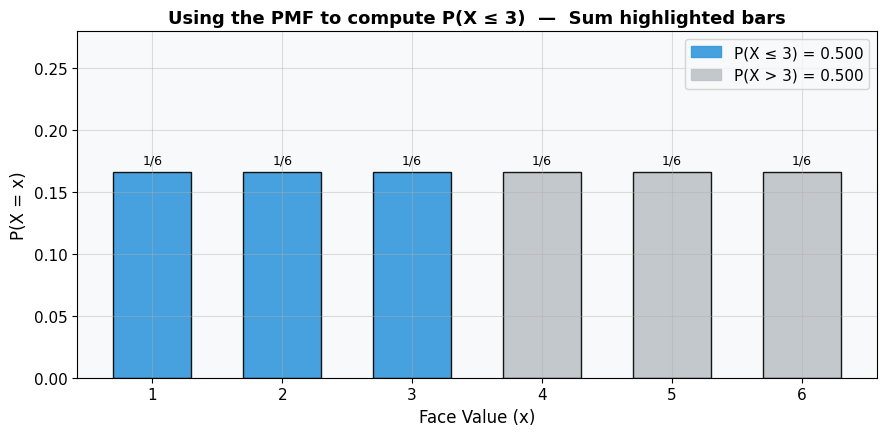

In [4]:
# --- Shaded PMF to show P(X <= 3) ---
values = np.arange(1, 7)
probs  = np.ones(6) / 6
threshold = 3

bar_colors = ['#3498db' if v <= threshold else '#bdc3c7' for v in values]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(values, probs, color=bar_colors, edgecolor='black', alpha=0.9, width=0.6)

for bar, p, v in zip(bars, probs, values):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.004,
            f'1/6', ha='center', va='bottom', fontsize=9)

prob_event = probs[values <= threshold].sum()
blue_patch  = mpatches.Patch(color='#3498db', alpha=0.9, label=f'P(X ≤ 3) = {prob_event:.3f}')
grey_patch  = mpatches.Patch(color='#bdc3c7', alpha=0.9, label=f'P(X > 3) = {1 - prob_event:.3f}')
ax.legend(handles=[blue_patch, grey_patch], fontsize=11)

ax.set_xlabel('Face Value (x)', fontsize=12)
ax.set_ylabel('P(X = x)', fontsize=12)
ax.set_title('Using the PMF to compute P(X ≤ 3)  —  Sum highlighted bars', fontsize=13, fontweight='bold')
ax.set_xticks(values)
ax.set_ylim(0, 0.28)
plt.tight_layout()
plt.show()

## PMF vs Histogram (Empirical vs Theoretical)

The **theoretical PMF** gives exact probabilities. When we **simulate** the experiment many times, the relative frequencies (empirical histogram) converge to the PMF as $n \to \infty$.

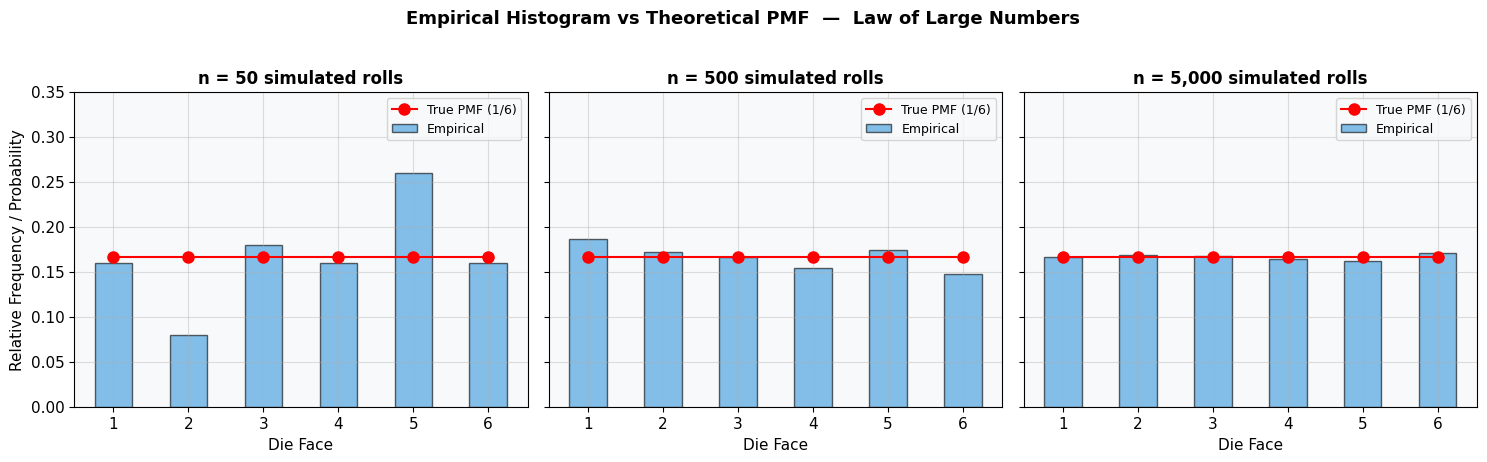

In [5]:
# --- Empirical vs Theoretical PMF ---
rng = np.random.default_rng(42)
n_trials_list = [50, 500, 5000]
x_true = np.arange(1, 7)
p_true = np.ones(6) / 6

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, n in zip(axes, n_trials_list):
    rolls = rng.integers(1, 7, size=n)
    counts = np.bincount(rolls, minlength=7)[1:]
    emp_probs = counts / n

    ax.bar(x_true, emp_probs, color='#3498db', edgecolor='black', alpha=0.6,
           width=0.5, label='Empirical')
    ax.plot(x_true, p_true, 'ro-', markersize=8, linewidth=1.5, label='True PMF (1/6)')
    ax.set_title(f'n = {n:,} simulated rolls', fontsize=12, fontweight='bold')
    ax.set_xlabel('Die Face')
    ax.set_xticks(x_true)
    if ax == axes[0]:
        ax.set_ylabel('Relative Frequency / Probability')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 0.35)

plt.suptitle('Empirical Histogram vs Theoretical PMF  —  Law of Large Numbers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## PMF Gallery — Common Discrete Distributions

| Distribution | PMF Formula | Support | Parameters |
|---|---|---|---|
| **Bernoulli** | $p^x(1-p)^{1-x}$ | $\{0, 1\}$ | $p \in [0,1]$ |
| **Binomial** | $\binom{n}{k}p^k(1-p)^{n-k}$ | $\{0,\ldots,n\}$ | $n, p$ |
| **Geometric** | $(1-p)^{k-1}p$ | $\{1, 2, 3,\ldots\}$ | $p$ |
| **Poisson** | $\dfrac{\lambda^k e^{-\lambda}}{k!}$ | $\{0, 1, 2,\ldots\}$ | $\lambda > 0$ |

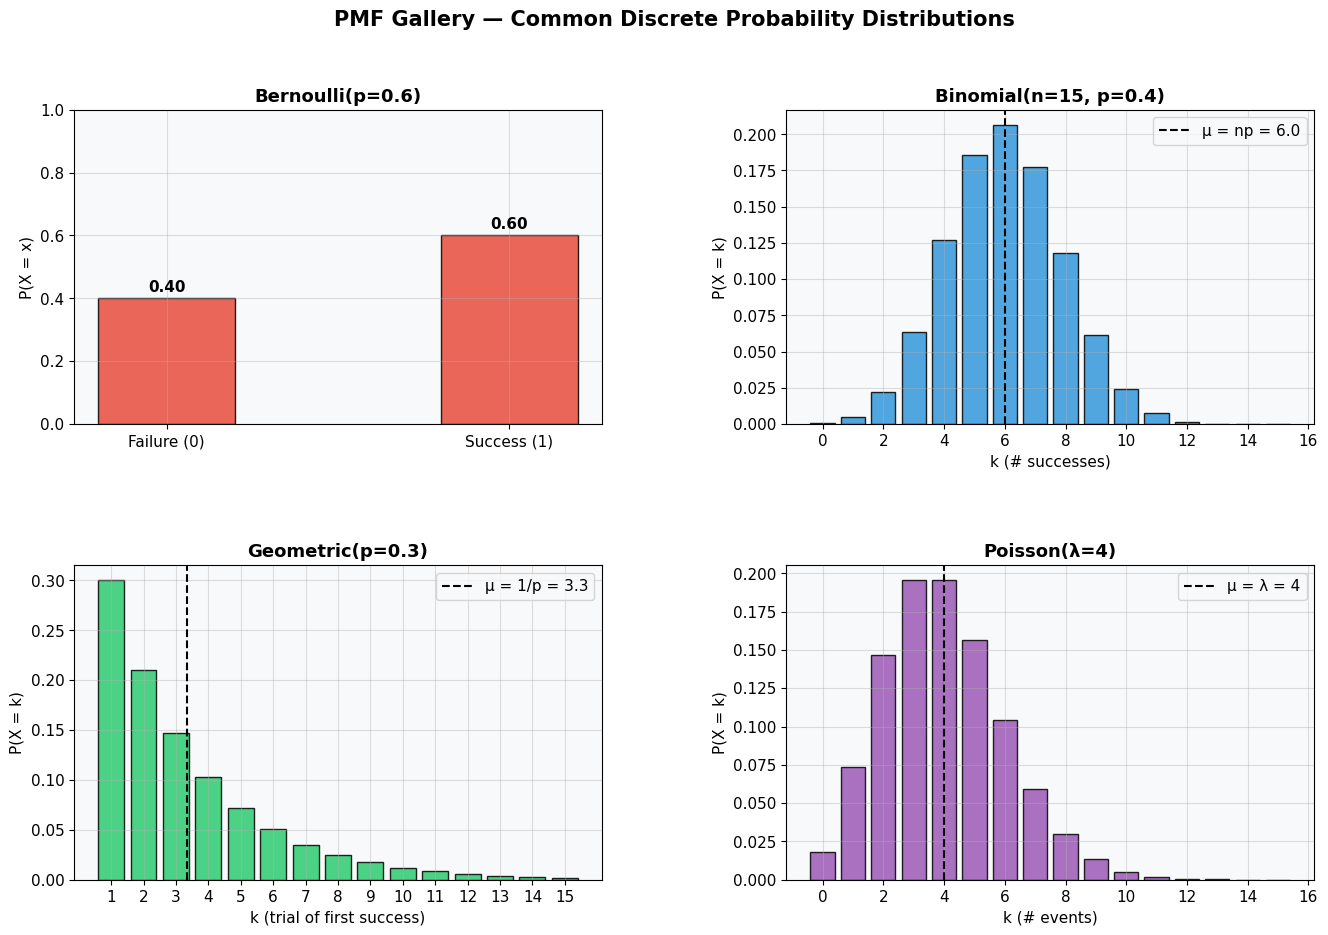

In [6]:
# --- PMF Gallery: 4 common discrete distributions ---
fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

palette = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

# 1. Bernoulli
ax1 = fig.add_subplot(gs[0, 0])
p_b = 0.6
xb  = [0, 1]
pb  = [1 - p_b, p_b]
bars = ax1.bar(xb, pb, color=palette[0], edgecolor='black', alpha=0.85, width=0.4)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Failure (0)', 'Success (1)'])
ax1.set_ylabel('P(X = x)')
ax1.set_title(f'Bernoulli(p={p_b})', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.0)
for bar, p in zip(bars, pb):
    ax1.text(bar.get_x() + bar.get_width()/2, p + 0.02, f'{p:.2f}',
             ha='center', fontsize=11, fontweight='bold')

# 2. Binomial
ax2 = fig.add_subplot(gs[0, 1])
n_bin, p_bin = 15, 0.4
k_bin = np.arange(0, n_bin + 1)
pmf_bin = binom.pmf(k_bin, n_bin, p_bin)
ax2.bar(k_bin, pmf_bin, color=palette[1], edgecolor='black', alpha=0.85)
mu_bin = n_bin * p_bin
ax2.axvline(mu_bin, color='black', linestyle='--', linewidth=1.5, label=f'μ = np = {mu_bin}')
ax2.set_xlabel('k (# successes)')
ax2.set_ylabel('P(X = k)')
ax2.set_title(f'Binomial(n={n_bin}, p={p_bin})', fontsize=13, fontweight='bold')
ax2.legend()

# 3. Geometric
ax3 = fig.add_subplot(gs[1, 0])
p_geo = 0.3
k_geo = np.arange(1, 16)
pmf_geo = geom.pmf(k_geo, p_geo)
ax3.bar(k_geo, pmf_geo, color=palette[2], edgecolor='black', alpha=0.85)
ax3.set_xlabel('k (trial of first success)')
ax3.set_ylabel('P(X = k)')
ax3.set_title(f'Geometric(p={p_geo})', fontsize=13, fontweight='bold')
ax3.set_xticks(k_geo)
mean_geo = 1 / p_geo
ax3.axvline(mean_geo, color='black', linestyle='--', linewidth=1.5, label=f'μ = 1/p = {mean_geo:.1f}')
ax3.legend()

# 4. Poisson
ax4 = fig.add_subplot(gs[1, 1])
lam = 4
k_poi = np.arange(0, 16)
pmf_poi = poisson.pmf(k_poi, lam)
ax4.bar(k_poi, pmf_poi, color=palette[3], edgecolor='black', alpha=0.85)
ax4.axvline(lam, color='black', linestyle='--', linewidth=1.5, label=f'μ = λ = {lam}')
ax4.set_xlabel('k (# events)')
ax4.set_ylabel('P(X = k)')
ax4.set_title(f'Poisson(λ={lam})', fontsize=13, fontweight='bold')
ax4.legend()

plt.suptitle('PMF Gallery — Common Discrete Probability Distributions',
             fontsize=15, fontweight='bold')
plt.show()

## PMF Properties Verification

For any valid PMF:

1. $P_X(x) \geq 0$ for all $x$
2. $\sum_x P_X(x) = 1$

In [7]:
# --- Property verification for all four distributions ---
distributions = {
    'Bernoulli(p=0.6)':    ([0, 1],             [0.4, 0.6]),
    'Binomial(15, 0.4)':   (k_bin,              pmf_bin),
    'Geometric(p=0.3)':    (np.arange(1, 500),  geom.pmf(np.arange(1, 500), 0.3)),
    'Poisson(λ=4)':        (np.arange(0, 500),  poisson.pmf(np.arange(0, 500), 4)),
}

print(f"{'Distribution':<25} {'Min P(x)':>10} {'Sum P(x)':>10} {'Valid?':>8}")
print("-" * 58)
for name, (xs, ps) in distributions.items():
    ps = np.array(ps)
    non_neg = bool(np.all(ps >= 0))
    total   = ps.sum()
    valid   = non_neg and np.isclose(total, 1.0, atol=1e-6)
    print(f"{name:<25} {ps.min():>10.4f} {total:>10.6f} {'✓' if valid else '✗':>8}")

Distribution                Min P(x)   Sum P(x)   Valid?
----------------------------------------------------------
Bernoulli(p=0.6)              0.4000   1.000000        ✓
Binomial(15, 0.4)             0.0000   1.000000        ✓
Geometric(p=0.3)              0.0000   1.000000        ✓
Poisson(λ=4)                  0.0000   1.000000        ✓


## Expected Value and Variance from the PMF

The PMF is used to compute summary statistics:

$$\mathbb{E}[X] = \sum_x x \cdot P_X(x)$$

$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \sum_x x^2 \cdot P_X(x) - \left(\sum_x x \cdot P_X(x)\right)^2$$

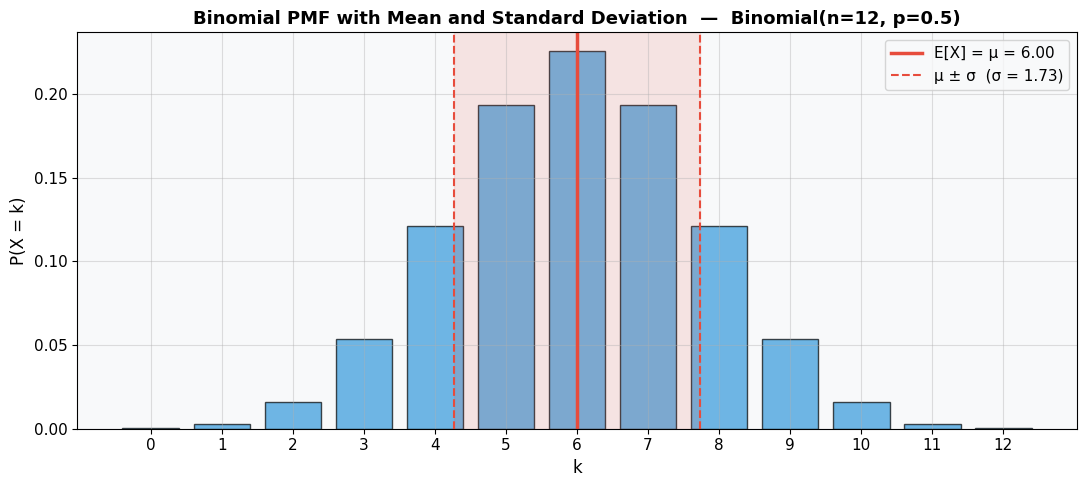

E[X]   = Σ x·P(X=x)       = 6.0000
E[X²]  = Σ x²·P(X=x)      = 39.0000
Var(X) = E[X²] - (E[X])²  = 3.0000
Std(X) = √Var(X)           = 1.7321


In [8]:
# --- Visualize E[X] on the PMF ---
n_bin, p_bin = 12, 0.5
k_vals = np.arange(0, n_bin + 1)
pmf    = binom.pmf(k_vals, n_bin, p_bin)

E_X   = np.sum(k_vals * pmf)
E_X2  = np.sum(k_vals**2 * pmf)
Var_X = E_X2 - E_X**2
std_X = np.sqrt(Var_X)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(k_vals, pmf, color='#3498db', edgecolor='black', alpha=0.7)

# Mark mean
ax.axvline(E_X, color='#e74c3c', linewidth=2.5, linestyle='-',
           label=f'E[X] = μ = {E_X:.2f}')
# Mark ±1 std
ax.axvline(E_X - std_X, color='#e74c3c', linewidth=1.5, linestyle='--',
           label=f'μ ± σ  (σ = {std_X:.2f})')
ax.axvline(E_X + std_X, color='#e74c3c', linewidth=1.5, linestyle='--')

# Shade ±1 std region
ax.axvspan(E_X - std_X, E_X + std_X, alpha=0.12, color='#e74c3c')

ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('P(X = k)', fontsize=12)
ax.set_title(f'Binomial PMF with Mean and Standard Deviation  —  Binomial(n={n_bin}, p={p_bin})',
             fontsize=13, fontweight='bold')
ax.set_xticks(k_vals)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"E[X]   = Σ x·P(X=x)       = {E_X:.4f}")
print(f"E[X²]  = Σ x²·P(X=x)      = {E_X2:.4f}")
print(f"Var(X) = E[X²] - (E[X])²  = {Var_X:.4f}")
print(f"Std(X) = √Var(X)           = {std_X:.4f}")

## PMF vs PDF — Discrete vs Continuous

| | **PMF** (Discrete) | **PDF** (Continuous) |
|---|---|---|
| Variable type | Countable values | Uncountable (interval) |
| Individual probability | $P(X = x) > 0$ possible | $P(X = x) = 0$ always |
| Summing/integrating | $\sum_x P_X(x) = 1$ | $\int_{-\infty}^{\infty} f(x)\,dx = 1$ |
| Event probability | $P(a \leq X \leq b) = \sum_{x=a}^{b} P_X(x)$ | $P(a \leq X \leq b) = \int_a^b f(x)\,dx$ |
| Examples | Die rolls, coin flips, counts | Height, weight, temperature |

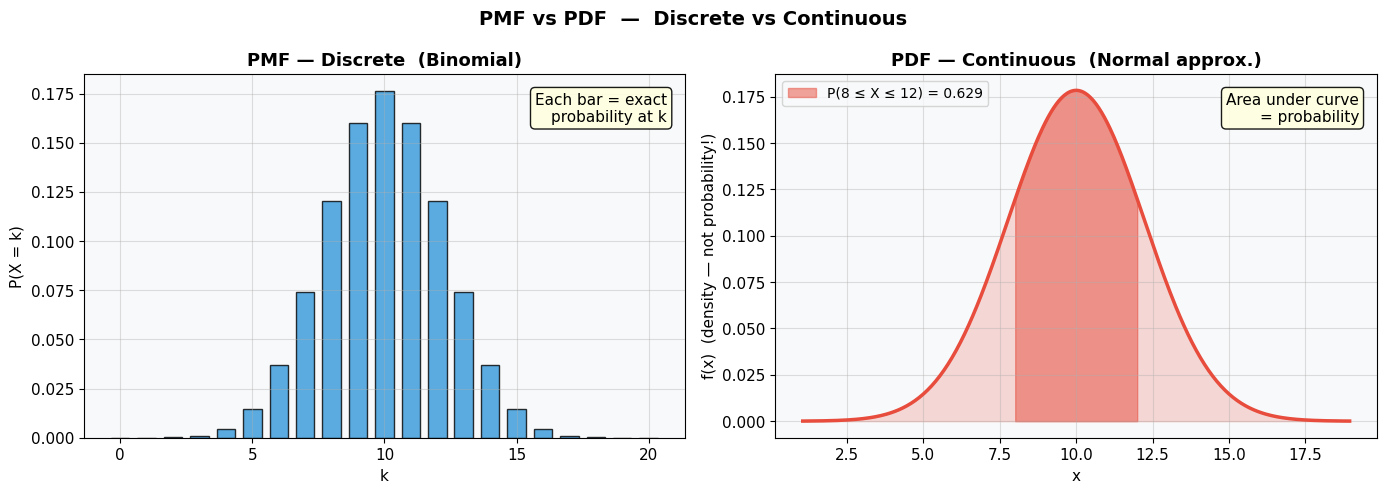

In [9]:
# --- Side-by-side: PMF (Binomial) vs PDF (Normal approximation) ---
from scipy.stats import norm

n, p = 20, 0.5
k    = np.arange(0, n + 1)
pmf  = binom.pmf(k, n, p)
mu, sigma = n * p, np.sqrt(n * p * (1 - p))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PMF
ax1 = axes[0]
ax1.bar(k, pmf, color='#3498db', edgecolor='black', alpha=0.8, width=0.7)
ax1.set_title('PMF — Discrete  (Binomial)', fontsize=13, fontweight='bold')
ax1.set_xlabel('k')
ax1.set_ylabel('P(X = k)')
ax1.text(0.97, 0.95, 'Each bar = exact\nprobability at k',
         transform=ax1.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# PDF
ax2 = axes[1]
x_cont = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf    = norm.pdf(x_cont, mu, sigma)
ax2.plot(x_cont, pdf, color='#e74c3c', linewidth=2.5)
ax2.fill_between(x_cont, pdf, alpha=0.2, color='#e74c3c')
# shade P(8 <= X <= 12)
mask = (x_cont >= 8) & (x_cont <= 12)
ax2.fill_between(x_cont[mask], pdf[mask], alpha=0.5, color='#e74c3c',
                 label=f'P(8 ≤ X ≤ 12) = {norm.cdf(12, mu, sigma) - norm.cdf(8, mu, sigma):.3f}')
ax2.set_title('PDF — Continuous  (Normal approx.)', fontsize=13, fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)  (density — not probability!)')
ax2.legend(fontsize=10)
ax2.text(0.97, 0.95, 'Area under curve\n= probability',
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle('PMF vs PDF  —  Discrete vs Continuous', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Concept | Key Idea |
|---|---|
| **PMF** | Maps each possible value of a discrete RV to its exact probability |
| **Properties** | Non-negative, sums to 1 |
| **Event probability** | Sum PMF values over the event's values |
| **CDF** | Cumulative sum of PMF: $F(x) = P(X \leq x)$ |
| **Mean** | $\mathbb{E}[X] = \sum x \cdot P_X(x)$ |
| **Variance** | $\text{Var}(X) = \sum x^2 P_X(x) - (\mathbb{E}[X])^2$ |
| **vs PDF** | PMF is for discrete; PDF is for continuous (area = probability) |